In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('matches.csv')

print("Shape of the dataset:", data.shape)
print("\nColumns in the dataset:", data.columns)
print("\nFirst few rows of the dataset:")
print(data.head())
print("\nInformation about the dataset:")
print(data.info())
print("\nMissing values in the dataset:")
print(data.isnull().sum())

Shape of the dataset: (1095, 20)

Columns in the dataset: Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

First few rows of the dataset:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  18-04-2008     League     BB McCullum   
1  335983  2007/08  Chandigarh  19-04-2008     League      MEK Hussey   
2  335984  2007/08       Delhi  19-04-2008     League     MF Maharoof   
3  335985  2007/08      Mumbai  20-04-2008     League      MV Boucher   
4  335986  2007/08     Kolkata  20-04-2008     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Associat

In [23]:
matches = data.dropna(subset=['winner'])
matches = data.drop(columns=[ 'city', 'player_of_match', 'result_margin', 'target_runs', 'target_overs', 'method', 'umpire1', 'umpire2', 'id', 'date' ])
matches = matches.dropna(subset=['winner'])
print("\nShape of the matches dataset:", matches.shape)
print("\nColumns in the matches dataset:", matches.columns.tolist())


Shape of the matches dataset: (1090, 10)

Columns in the matches dataset: ['season', 'match_type', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'super_over']


In [24]:
print("Value counts for winner:")
print(data.value_counts('winner').head(10))
print("\nValue counts for venue:")
print(data.value_counts('venue').head(10))

Value counts for winner:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

Value counts for venue:
venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


In [25]:
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']
print(matches['toss_won_match'].value_counts())

print("\nValue counts for toss_decision:")
print(matches.value_counts('toss_decision'))

print("\nValue counts for result:")
print(matches.value_counts('result'))

print("\nValue counts for super over:")
print(matches.value_counts('super_over'))

toss_won_match
True     554
False    536
Name: count, dtype: int64

Value counts for toss_decision:
toss_decision
field    700
bat      390
Name: count, dtype: int64

Value counts for result:
result
wickets    578
runs       498
tie         14
Name: count, dtype: int64

Value counts for super over:
super_over
N    1076
Y      14
Name: count, dtype: int64


In [26]:
field_first =matches[matches['toss_decision'] == 'field']
field_wins = (field_first['toss_winner'] == field_first['winner']).mean()
print("Win rate when choosing to field:", round(field_wins,3))

bat_first = matches[matches['toss_decision'] == 'bat']
bat_wins = (bat_first['toss_winner'] == bat_first['winner']).mean()
print("Win rate when choosing to bat:", round(bat_wins,3))

Win rate when choosing to field: 0.539
Win rate when choosing to bat: 0.454


In [27]:
matches = matches.drop(columns=['result','super_over','toss_won_match'])

print("\nShape:", matches.shape)
print("\nColumns:", matches.columns.tolist())

matches['season'] = matches['season'].str[:4].astype(int)
print(matches['season'].unique())



Shape: (1090, 8)

Columns: ['season', 'match_type', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner']
[2007 2009 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


In [28]:
team_mapping= {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Deccan Chargers': 'Sunrisers Hyderabad',   
}

matches['winner'] = matches['winner'].replace(team_mapping)
matches['team1'] = matches['team1'].replace(team_mapping)
matches['team2'] = matches['team2'].replace(team_mapping)
matches['toss_winner'] = matches['toss_winner'].replace(team_mapping)
matches['winner'] = matches['winner'].replace(team_mapping)


print(sorted(matches['winner'].unique()))

defunct_teams = ['Rising Pune Supergiants', 'Gujarat Lions', 'Pune Warriors', 'Kochi Tuskers Kerala']
matches = matches[~matches['winner'].isin(defunct_teams)]
print("\nShape after removing defunct teams:", matches.shape)



['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Shape after removing defunct teams: (1044, 8)


In [29]:
venue_mapping = {
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium, Ahmedabad',
}

matches['venue'] = matches['venue'].replace(venue_mapping)
print(matches['venue'].nunique())

39


In [30]:
#Calculate win match for each team up to each match

def get_win_rates(matches):
    win_rates={}
    team1_wr=[]
    team2_wr=[]

    for idx, row in matches.iterrows():
        t1=row['team1']
        t2=row['team2']

        #get win rate BEFORE this match
        t1_wr=win_rates.get(t1,{}).get('wins',0)/ max(win_rates.get(t1,{}).get('games',1),1)
        t2_wr=win_rates.get(t2,{}).get('wins',0)/ max(win_rates.get(t2,{}).get('games',1),1)

        team1_wr.append(round(t1_wr,3))
        team2_wr.append(round(t2_wr,3))

        #update win rates after this match
        winner=row['winner']
        for team in [t1,t2]:
            if team not in win_rates:
                win_rates[team]={'wins':0,'games':0}
            win_rates[team]['games']+=1
            if team == winner:
                win_rates[team]['wins']+=1

    matches['team1_win_rate']=team1_wr
    matches['team2_win_rate']=team2_wr
    return matches

matches = get_win_rates(matches)
print(matches[['team1','team1_win_rate','team2','team2_win_rate']].head(10))
"\n\n"
def get_head_to_head(matches):
    h2h={}
    h2h_rates=[]

    for idx, row in matches.iterrows():
        t1=row['team1']
        t2=row['team2']

        key = tuple(sorted([t1,t2]))

        if key not in h2h:
            h2h[key] = {'t1_wins':0, 'total':0}

        #Get head to head rate BEFORE this match
        total = h2h[key]['total']
        if total == 0:
            h2h_rates.append(0.5)  # No history, assume equal chances
        else:
            t1_wins = h2h[key]['t1_wins']
            h2h_rates.append(round(t1_wins / total, 3))

        #Update head to head after this match
        h2h[key]['total'] += 1
        if row['winner'] == t1:
            h2h[key]['t1_wins'] += 1

    matches['h2h_win_rate'] = h2h_rates
    return matches

matches = get_head_to_head(matches)
print(matches[['team1','team2','h2h_win_rate']].head(10))
"\n\n"
def get_venue_win_rate(matches):
    venue_wins={}
    venue_rates=[]

    for idx, row in matches.iterrows():
        t1=row['team1']
        venue=row['venue']
        key = (t1, venue)

        if key not in venue_wins:
            venue_wins[key] = {'wins':0, 'games':0}

        #Get venue win rate BEFORE this match
        games = venue_wins[key]['games']
        if games == 0:
            venue_rates.append(0.5)  # No history, assume equal chances
        else:
            venue_rates.append(round(venue_wins[key]['wins'] / games, 3))

        #Update venue wins after this match
        venue_wins[key]['games'] += 1
        if row['winner'] == t1:
            venue_wins[key]['wins'] += 1

    matches['team1_venue_win_rate'] = venue_rates
    return matches

matches = get_venue_win_rate(matches)
print(matches[['team1','venue','team1_venue_win_rate']].head(10))

                         team1  team1_win_rate                        team2  \
0  Royal Challengers Bengaluru             0.0        Kolkata Knight Riders   
1                 Punjab Kings             0.0          Chennai Super Kings   
2               Delhi Capitals             0.0             Rajasthan Royals   
3               Mumbai Indians             0.0  Royal Challengers Bengaluru   
4        Kolkata Knight Riders             1.0          Sunrisers Hyderabad   
5             Rajasthan Royals             0.0                 Punjab Kings   
6          Sunrisers Hyderabad             0.0               Delhi Capitals   
7          Chennai Super Kings             1.0               Mumbai Indians   
8          Sunrisers Hyderabad             0.0             Rajasthan Royals   
9                 Punjab Kings             0.0               Mumbai Indians   

   team2_win_rate  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  
5         

In [31]:
def get_recent_form(matches,n=5):
    team_history = {}
    team1_form=[]
    team2_form=[]

    for idx, row in matches.iterrows():
        t1=row['team1']
        t2=row['team2']

        #get recent form BEFORE this match
        t1_history=team_history.get(t1,[])
        t2_history=team_history.get(t2,[])

        t1_recent = sum(t1_history[-n:]) / min(len(t1_history), n) if t1_history else 0.5
        t2_recent = sum(t2_history[-n:]) / min(len(t2_history), n) if t2_history else 0.5

        team1_form.append(round(t1_recent,3))
        team2_form.append(round(t2_recent,3))

        #update history after this match
        for team in [t1,t2]:
            if team not in team_history:
                team_history[team] = []
            team_history[team].append(1 if row['winner'] == team else 0)

    matches['team1_recent_form'] = team1_form
    matches['team2_recent_form'] = team2_form
    return matches

matches = get_recent_form(matches)
print(matches[['team1','team1_recent_form','team2','team2_recent_form']].head(10))

                         team1  team1_recent_form  \
0  Royal Challengers Bengaluru                0.5   
1                 Punjab Kings                0.5   
2               Delhi Capitals                0.5   
3               Mumbai Indians                0.5   
4        Kolkata Knight Riders                1.0   
5             Rajasthan Royals                0.0   
6          Sunrisers Hyderabad                0.0   
7          Chennai Super Kings                1.0   
8          Sunrisers Hyderabad                0.0   
9                 Punjab Kings                0.0   

                         team2  team2_recent_form  
0        Kolkata Knight Riders                0.5  
1          Chennai Super Kings                0.5  
2             Rajasthan Royals                0.5  
3  Royal Challengers Bengaluru                0.0  
4          Sunrisers Hyderabad                0.5  
5                 Punjab Kings                0.0  
6               Delhi Capitals                1.0  


In [32]:
from sklearn.model_selection import train_test_split

#Separating features and target variable
X = pd.get_dummies(matches.drop(columns=['winner']), 
                   columns=['match_type', 'venue', 'team1', 'team2', 
                            'toss_decision', 'toss_winner'], 
                   drop_first=True)
y = matches['winner']

#Remove defunct team columns
defunct_cols = [col for col in X.columns if any(team in col for team in ['Rising Pune Supergiants', 'Gujarat Lions', 'Pune Warriors', 'Kochi Tuskers Kerala'])]
X = X.drop(columns=defunct_cols)
print("New X Shape:", X.shape)

#Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nX shape:", X.shape)
print("\nTraining set shape:", X_train.shape)
print("\nTesting set shape:", X_test.shape)

New X Shape: (1044, 80)

X shape: (1044, 80)

Training set shape: (835, 80)

Testing set shape: (209, 80)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the models
#Logistic Regression
lr_model=LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, lr_pred))

#Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))

#K-Nearest Neighbors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
print("\nK-Nearest Neighbors Accuracy:", accuracy_score(y_test, knn_pred))    
print("\nClassification Report for K-Nearest Neighbors:")
print(classification_report(y_test, knn_pred))



c:\Users\61IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.5598086124401914

Classification Report for Logistic Regression:
                             precision    recall  f1-score   support

        Chennai Super Kings       0.68      0.38      0.49        34
             Delhi Capitals       0.43      0.71      0.54        21
             Gujarat Titans       0.60      0.50      0.55         6
      Kolkata Knight Riders       0.67      0.75      0.71        24
       Lucknow Super Giants       1.00      0.50      0.67         6
             Mumbai Indians       0.61      0.77      0.68        30
               Punjab Kings       0.48      0.37      0.42        27
           Rajasthan Royals       0.55      0.50      0.52        22
Royal Challengers Bengaluru       0.54      0.54      0.54        24
        Sunrisers Hyderabad       0.47      0.53      0.50        15

                   accuracy                           0.56       209
                  macro avg       0.60      0.56      0.56       209
    

In [34]:
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X, y, cv=5)
print("Logistic Regression Cross-Validation Scores:", lr_cv)
print("Average CV Accuracy for Logistic Regression:", lr_cv.mean())

rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5)
print("\nRandom Forest Cross-Validation Scores:", rf_cv)
print("Average CV Accuracy for Random Forest:", rf_cv.mean())

knn_cv = cross_val_score(KNeighborsClassifier(n_neighbors=5), scaler.fit_transform(X), y, cv=5)
print("\nK-Nearest Neighbors Cross-Validation Scores:", knn_cv)
print("Average CV Accuracy for K-Nearest Neighbors:", knn_cv.mean())

c:\Users\61IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\61IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

Logistic Regression Cross-Validation Scores: [0.48803828 0.6076555  0.57894737 0.44497608 0.47596154]
Average CV Accuracy for Logistic Regression: 0.5191157526683842

Random Forest Cross-Validation Scores: [0.44019139 0.57894737 0.59808612 0.47368421 0.39903846]
Average CV Accuracy for Random Forest: 0.49798951048951057

K-Nearest Neighbors Cross-Validation Scores: [0.45933014 0.51196172 0.46411483 0.41148325 0.36538462]
Average CV Accuracy for K-Nearest Neighbors: 0.442454913507545


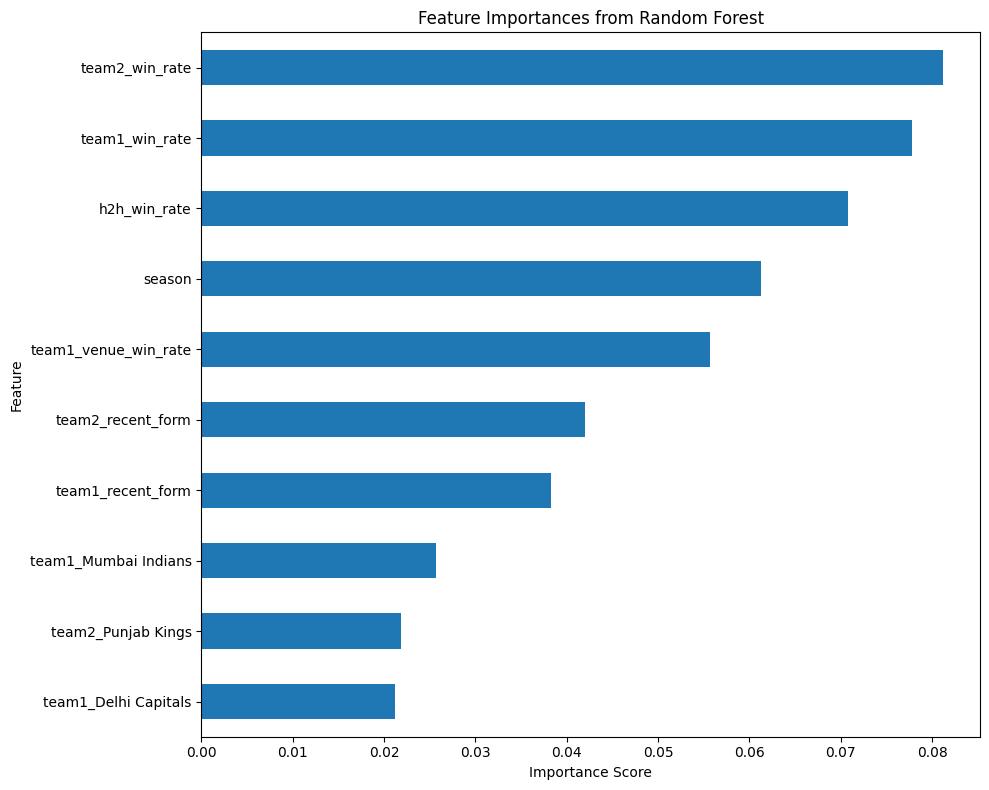

In [35]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(10).plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [37]:
import joblib
joblib.dump(lr_model, 'ipl_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')
joblib.dump(sorted(matches['venue'].unique().tolist()), 'venues.pkl')
print("All files saved!")

All files saved!
